# H-002 · Does a High GK / Realised Vol Ratio Predict Reversal?

Factor test for **H-002** (equities): whether a high short-window Garman–Klass (intraday OHLC) vol relative to longer-window close-to-close realised vol predicts negative next-week returns.

- **Idea** — Ratio of short-window average GK vol to longer-window realised vol; high values flag intraday stress not fully reflected in closes.
- **Claim** — High GK/realised vol ratio predicts negative next-week returns (short-horizon mean reversion).
- **Why it might work** — Wide intraday ranges with muted close-to-close vol suggest two-way fighting or intraday overreaction that partially reverses.
- **Data** — Daily OHLC long panel (`open`, `high`, `low`, `close`).

**No floor / no winsorize in the feature store:** `add_gk_vol_ratio` does **not** floor the realised-vol denominator (non-positive → NaN ratio) and does **not** winsorize the ratio. If you need winsorization, apply it in §2 (project cleaners) before or after the store call — not inside the factor API.

**`normalize` (default `True`):** when `normalize=True`, `add_gk_vol_ratio` stores a **cross-sectional (CS)** feature — the percentile rank of the mode-transformed ratio *within each date*. That is GBM-ready and comparable across names. Set `normalize=False` to keep the unranked value.

**Defaults:** `gk_window=5`, `realised_window=20` (override only with keyword args, e.g. `gk_window=10`). Realised vol is the population std of the last `realised_window` log close-to-close returns ending at `t`.

**Realised-vol std (current implementation):** population standard deviation (`ddof=0`) of the last `realised_window` log returns ending at `t`. Prefer `ddof=0` over sample std (`ddof=1`) for this factor; with `normalize=True`, CS ranks are unchanged either way. This is **not** a keyword on `add_gk_vol_ratio`.

<small>To change: edit the hard-coded `.std(ddof=0)` inside `realised_vol` in `01_data/processing/feature_implementation/gk_vol_ratio.py` (use `ddof=1` only to match a sample-std library).</small>

**`mode` options** (column `gk_vol_{mode}` or `gk_vol_{mode}_{gkW}_{realW}` when multi-window):

| Mode | Behavior |
|------|----------|
| `ratio` (default) | Raw short-GK-mean / realised-vol (high = more intraday stress). |
| `log_ratio` | `ln` of the ratio when positive; non-positive → NaN. With `normalize=True`, CS ranks match `ratio` when the ratio is positive (monotonic). |
| `reversal` | Negated raw ratio so higher values ≈ more bullish expected return. |

**Multi-window:** `gk_window` and `realised_window` each accept an `int` or a list (cartesian product). One combo → `gk_vol_{mode}`; multiple → `gk_vol_{mode}_{gkW}_{realW}`.

**Research IS:** load `s1_factor_panel_train.parquet` (train / research IS from the panel notebook; `RESEARCH_IS_FRACTION`, default `0.70`). Do not re-split it. Full census is `s1_factor_panel_full.parquet` (not for factor IC keep/kill). For **S1 equities** factor screens, Alphalens `periods=(1, 5, 21)` on the daily panel is the intended default (other sleeves may use different periods).

Use `data.processing.feature_store.add_gk_vol_ratio` rather than reimplementing the factor inline.

## 0. Imports & Config

Resolve the repo root, configure factor params (`gk_window`, `realised_window` as int or list; `mode`, `normalize`), and import `s1_factor_panel_train.parquet`, `add_gk_vol_ratio`, and Alphalens. The train parquet is already research IS; do not calculate another cutoff here.

In [1]:
import os
import sys

import alphalens as al
import pandas as pd

from data.processing.cleaner import forward_fill_panel
from data.processing.feature_store import add_gk_vol_ratio

# Jupyter cwd is often this notebook's folder, not the repo root; walk up until we find 01_data/ingestion.
ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

TRAIN_PANEL_PATH = os.path.join(
    ROOT, "01_data", "data_files", "s1_equities", "s1_factor_panel_train.parquet"
)

# --- Window screen (edit these lists) ---
GK_WINDOWS = [3, 5, 10]           # gkW — short GK mean window
REALISED_WINDOWS = [10, 20, 63]   # realW — realised-vol length
# Cartesian product: every (gkW, realW) is tested below via the store (per mode).

# --- Modes screened (all three) ---
MODES = ["ratio", "log_ratio", "reversal"]

# --- Fixed for this notebook (not screened) ---
NORMALIZE = True      # fixed
PERIODS = (1, 5, 21)  # fixed — H-002 / S1 default; primary narrative = 5d
QUANTILES = 5
MAX_LOSS = 0.35


## 1. Data Loading

Load `s1_factor_panel_train.parquet`, which contains the daily OHLC chronological research IS selected by `RESEARCH_IS_FRACTION` in the panel notebook. Confirm columns: `date`, `ticker`, `open`, `high`, `low`, `close`.

Do not apply another 70/30 split in this notebook.

In [2]:
panel = pd.read_parquet(TRAIN_PANEL_PATH)
required = {"date", "ticker", "open", "high", "low", "close"}
missing = required - set(panel.columns)
if missing:
    raise ValueError(f"train panel missing columns: {sorted(missing)}")

panel = panel.copy()
panel["date"] = pd.to_datetime(panel["date"])
print(f"rows={len(panel):,}  tickers={panel['ticker'].nunique():,}  "
      f"dates={panel['date'].nunique():,}  "
      f"[{panel['date'].min().date()} → {panel['date'].max().date()}]")
panel.head()


rows=115,000  tickers=100  dates=1,150  [2020-01-02 → 2024-07-29]


,date,ticker,open,high,low,close,volume
0,2020-01-02,AAPL,71.344062,72.394093,71.091191,72.333885,135480400
1,2020-01-02,ABBV,67.852721,68.225955,67.418550,68.210724,5639200
2,2020-01-02,ABT,75.995215,76.789960,75.765627,76.781128,4969000
3,2020-01-02,ACN,189.265376,190.216817,187.425318,188.628082,2431100
4,2020-01-02,ADBE,330.000000,334.480011,329.170013,334.429993,1990100


## 2. Data Cleaning & Engineering

Clean the long panel as needed (missing bars, optional winsorize, etc.) via project cleaners. Stay in **long format**.

The feature store itself does **not** winsorize or floor the denominator — do that here if desired.

Point-in-time only: features at `t` use information available at or before `t`.

In [3]:
ohlc = ["open", "high", "low", "close"]
panel = forward_fill_panel(panel, columns=ohlc, limit=5)
panel = panel.dropna(subset=ohlc).reset_index(drop=True)
print(f"after clean: rows={len(panel):,}  "
      f"null OHLC={panel[ohlc].isna().any(axis=1).sum()}")


after clean: rows=115,000  null OHLC=0


## 3. Modeling / Signal Construction

Build the GK vol ratio on the cleaned panel.

### 3.1 GK / realised vol ratio (H-002)

Call `add_gk_vol_ratio` with the chosen `mode` and `normalize`.

- With `normalize=True`, output is a **CS-ranked** feature (`gk_vol_{mode}`).
- With `normalize=False`, output is the unranked mode-transformed ratio.
- Optionally run more than one `mode` (`ratio` / `log_ratio` / `reversal`) side by side for sensitivity — note which is primary.

In [4]:
for mode in MODES:
    panel = add_gk_vol_ratio(
        panel,
        gk_window=GK_WINDOWS,
        realised_window=REALISED_WINDOWS,
        mode=mode,
        normalize=NORMALIZE,
    )

FACTOR_COLS = [c for c in panel.columns if c.startswith("gk_vol_")]
print(f"GK factors ({len(FACTOR_COLS)}):")
for c in FACTOR_COLS:
    print(f"  {c}")


GK factors (27):
  gk_vol_ratio_3_10
  gk_vol_ratio_3_20
  gk_vol_ratio_3_63
  gk_vol_ratio_5_10
  gk_vol_ratio_5_20
  gk_vol_ratio_5_63
  gk_vol_ratio_10_10
  gk_vol_ratio_10_20
  gk_vol_ratio_10_63
  gk_vol_log_ratio_3_10
  gk_vol_log_ratio_3_20
  gk_vol_log_ratio_3_63
  gk_vol_log_ratio_5_10
  gk_vol_log_ratio_5_20
  gk_vol_log_ratio_5_63
  gk_vol_log_ratio_10_10
  gk_vol_log_ratio_10_20
  gk_vol_log_ratio_10_63
  gk_vol_reversal_3_10
  gk_vol_reversal_3_20
  gk_vol_reversal_3_63
  gk_vol_reversal_5_10
  gk_vol_reversal_5_20
  gk_vol_reversal_5_63
  gk_vol_reversal_10_10
  gk_vol_reversal_10_20
  gk_vol_reversal_10_63


## 4. Evaluation

Quintile spread and IC of GK vol ratio vs forward returns on the research IS from `s1_factor_panel_train.parquet`. For **S1 equities**, use Alphalens `periods=(1, 5, 21)` on the daily panel (primary narrative 5d); other strategies may choose different periods. Screen window lists on this IS only. Report net of spread/slippage (reversal is turnover-sensitive).

### 4.1 Window screen summary

Factor column names encode mode and windows. Lists `GK_WINDOWS` × `REALISED_WINDOWS` are **cartesian-producted** in `add_gk_vol_ratio` for each entry in `MODES`.

| Token | Meaning | Formula / role |
|-------|---------|----------------|
| **mode** | Transform of the GK/realised ratio | `ratio` / `log_ratio` / `reversal` (all screened) |
| **gkW** (`gk_window`) | Short GK mean window | Mean of daily Garman–Klass vol over gkW days |
| **realW** (`realised_window`) | Realised-vol length | Population std of the last realW log close-to-close returns |

**Column pattern:** `gk_vol_{mode}_{gkW}_{realW}` — e.g. `gk_vol_ratio_5_20`

With `normalize=True`, CS ranks of `ratio` and `log_ratio` coincide when the ratio is positive (monotonic). Primary ranking metric below: **mean IC at 5d** (`ic_5d`).


In [5]:
def to_alphalens_prices(panel: pd.DataFrame) -> pd.DataFrame:
    """Wide close matrix for Alphalens only (dates × tickers)."""
    prices = panel.pivot(index="date", columns="ticker", values="close")
    prices.index = pd.to_datetime(prices.index)
    return prices.sort_index()


def to_alphalens_factor(panel: pd.DataFrame, col: str) -> pd.Series:
    """MultiIndex (date, ticker) factor series for Alphalens."""
    factor = panel.set_index(["date", "ticker"])[col].dropna()
    factor.index = factor.index.set_levels(
        pd.to_datetime(factor.index.levels[0]), level=0
    )
    return factor.sort_index()


def parse_factor_name(col: str) -> dict:
    """Decode ``gk_vol_{mode}_{gkW}_{realW}`` (mode may contain underscores, e.g. log_ratio)."""
    if not col.startswith("gk_vol_"):
        raise ValueError(f"unrecognized factor column: {col!r}")
    rest = col[len("gk_vol_"):]
    parts = rest.rsplit("_", 2)
    if len(parts) != 3:
        raise ValueError(f"expected gk_vol_{{mode}}_{{gkW}}_{{realW}}, got {col!r}")
    mode, gk_w, real_w = parts
    return {"mode": mode, "gkW": int(gk_w), "realW": int(real_w)}


def _period_label(period_index: pd.Index, period: int, position: int):
    """Match Alphalens period label ('1D', '5D', …) or fall back by position."""
    for c in (f"{period}D", f"{period}d", period, str(period)):
        if c in period_index:
            return c
    return period_index[position]


def factor_screen_metrics(
    factor: pd.Series,
    prices: pd.DataFrame,
    *,
    periods: tuple[int, ...] = PERIODS,
    quantiles: int = QUANTILES,
    max_loss: float = MAX_LOSS,
) -> dict:
    """Mean IC and Q5−Q1 mean return spread for each forward period."""
    factor_data = al.utils.get_clean_factor_and_forward_returns(
        factor=factor,
        prices=prices,
        quantiles=quantiles,
        periods=periods,
        max_loss=max_loss,
    )
    mean_ic = al.performance.mean_information_coefficient(factor_data)
    mean_ret, _ = al.performance.mean_return_by_quantile(factor_data, demeaned=True)

    row = {}
    for i, p in enumerate(periods):
        ic_key = _period_label(mean_ic.index, p, i)
        ret_key = _period_label(mean_ret.columns, p, i)
        row[f"ic_{p}d"] = float(mean_ic.loc[ic_key])
        q_hi, q_lo = mean_ret.index.max(), mean_ret.index.min()
        row[f"spread_{p}d"] = float(
            mean_ret.loc[q_hi, ret_key] - mean_ret.loc[q_lo, ret_key]
        )
    return row


In [6]:
prices = to_alphalens_prices(panel)

rows = []
for col in FACTOR_COLS:
    meta = parse_factor_name(col)
    metrics = factor_screen_metrics(to_alphalens_factor(panel, col), prices)
    rows.append({"factor": col, **meta, **metrics})

summary = (
    pd.DataFrame(rows)
    .sort_values("ic_5d", ascending=False)
    .reset_index(drop=True)
)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.4f}".format)
summary


Dropped 1.8% entries from factor data: 1.8% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 1.9% entries from factor data: 1.9% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 1.9% entries from factor data: 1.9% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 1.8% entries from factor data: 1.8% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 1.9% entries from factor data: 1.9% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 1.9% en

,factor,mode,gkW,realW,ic_1d,spread_1d,ic_5d,spread_5d,ic_21d,spread_21d
0,gk_vol_reversal_5_63,reversal,5,63,0.0047,0.0002,0.0140,0.0012,0.0153,0.0027
1,gk_vol_reversal_10_63,reversal,10,63,0.0059,0.0003,0.0114,0.0013,0.0143,0.0032
2,gk_vol_reversal_3_63,reversal,3,63,0.0024,0.0001,0.0091,0.0008,0.0129,0.0023
3,gk_vol_reversal_5_10,reversal,5,10,-0.0025,0.0001,0.0087,0.0015,0.0154,0.0041
4,gk_vol_reversal_10_10,reversal,10,10,-0.0019,0.0001,0.0067,0.0013,0.0139,0.0042
5,gk_vol_reversal_5_20,reversal,5,20,-0.0040,0.0000,0.0061,0.0009,0.0158,0.0036
6,gk_vol_reversal_3_10,reversal,3,10,-0.0028,0.0001,0.0061,0.0013,0.0121,0.0039
7,gk_vol_reversal_10_20,reversal,10,20,-0.0043,0.0001,0.0040,0.0014,0.0167,0.0043
8,gk_vol_reversal_3_20,reversal,3,20,-0.0036,0.0000,0.0034,0.0008,0.0135,0.0034
9,gk_vol_log_ratio_3_20,log_ratio,3,20,0.0036,-0.0000,-0.0034,-0.0008,-0.0135,-0.0034


### 4.2 Full tear sheet (manual GK combo)

Review the summary table in §4.1, then set `TEAR_MODE`, `TEAR_GK_WINDOW` (gkW), and `TEAR_REALISED_WINDOW` (realW) in the cell below. The tear sheet runs on `gk_vol_{mode}_{gkW}_{realW}` for those values — nothing is auto-selected.


In [7]:
def gk_factor_col(mode: str, gk_window: int, realised_window: int) -> str:
    """Column name for a multi-window GK factor: ``gk_vol_{mode}_{gkW}_{realW}``."""
    return f"gk_vol_{mode}_{gk_window}_{realised_window}"


def run_full_tear(
    panel: pd.DataFrame,
    factor_col: str,
    prices: pd.DataFrame,
    *,
    periods: tuple[int, ...] = PERIODS,
    quantiles: int = QUANTILES,
    max_loss: float = MAX_LOSS,
):
    """Build factor_data and run Alphalens full tear sheet."""
    if factor_col not in panel.columns:
        raise ValueError(
            f"{factor_col!r} not in panel — pick mode/gkW/realW that were screened "
            f"(available: {FACTOR_COLS})"
        )
    factor_data = al.utils.get_clean_factor_and_forward_returns(
        factor=to_alphalens_factor(panel, factor_col),
        prices=prices,
        quantiles=quantiles,
        periods=periods,
        max_loss=max_loss,
    )
    al.tears.create_full_tear_sheet(factor_data, long_short=True)
    return factor_data


Tear sheet factor: gk_vol_reversal_5_63
Dropped 1.9% entries from factor data: 1.9% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,0.0100,0.2000,0.1050,0.0577,21320,20.0000
2,0.2100,0.4000,0.3050,0.0577,21320,20.0000
3,0.4100,0.6000,0.5050,0.0577,21320,20.0000
4,0.6100,0.8000,0.7050,0.0577,21320,20.0000
5,0.8100,1.0000,0.9050,0.0577,21320,20.0000


Returns Analysis


,1D,5D,21D
Ann. alpha,0.0080,0.0080,-0.0060
beta,0.0640,0.0900,0.1140
Mean Period Wise Return Top Quantile (bps),0.1810,0.8820,0.1650
Mean Period Wise Return Bottom Quantile (bps),-1.4730,-1.5580,-1.1290
Mean Period Wise Spread (bps),1.6540,2.4540,1.2770


<Figure size 640x480 with 0 Axes>

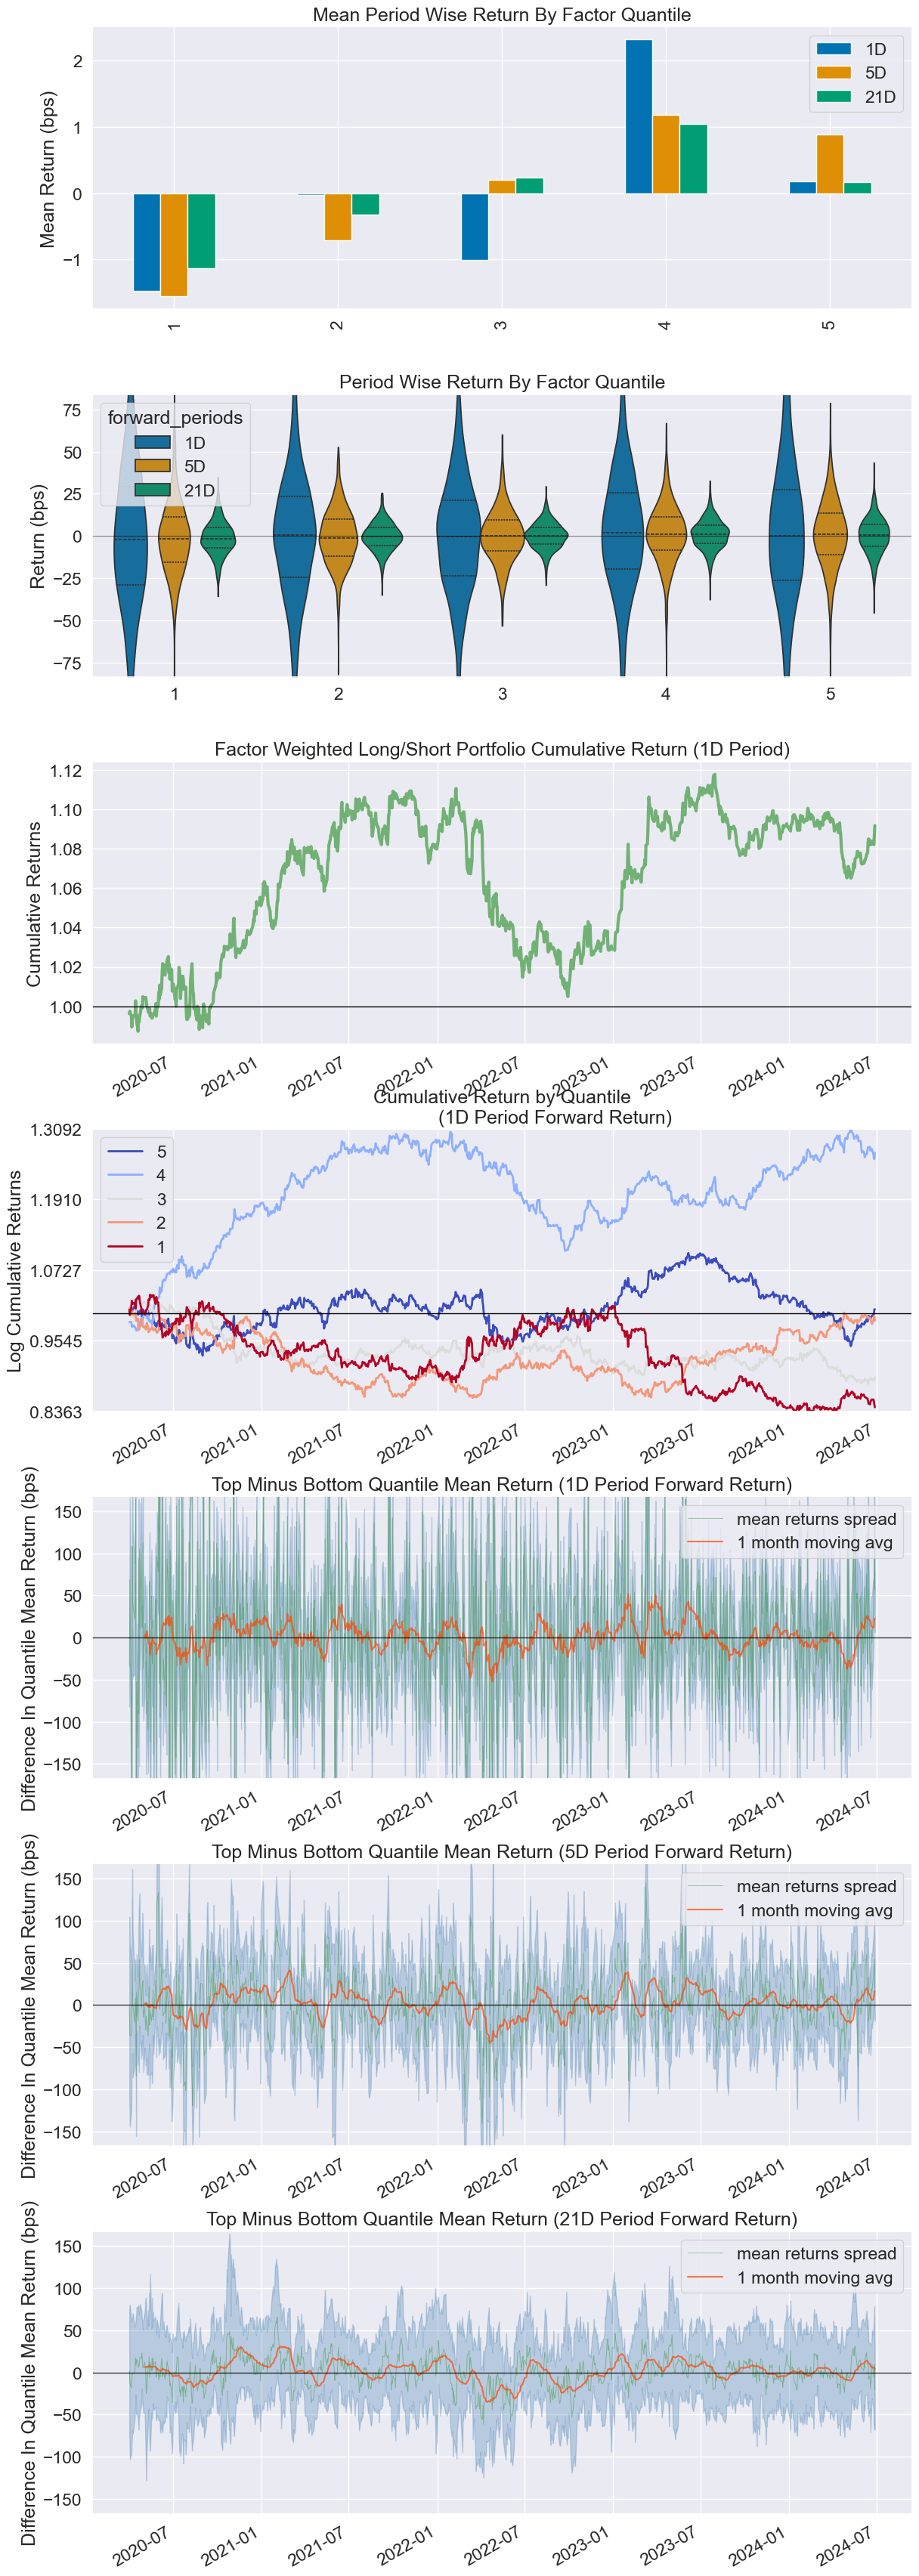

Information Analysis


,1D,5D,21D
IC Mean,0.0050,0.0140,0.0150
IC Std.,0.1770,0.1690,0.1640
Risk-Adjusted IC,0.0270,0.0830,0.0930
t-stat(IC),0.8750,2.7080,3.0410
p-value(IC),0.3820,0.0070,0.0020
IC Skew,0.0380,-0.1790,-0.2310
IC Kurtosis,-0.0740,0.1680,-0.2450


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\alphalens\performance.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouper.append(pd.Grouper(freq=by_time))


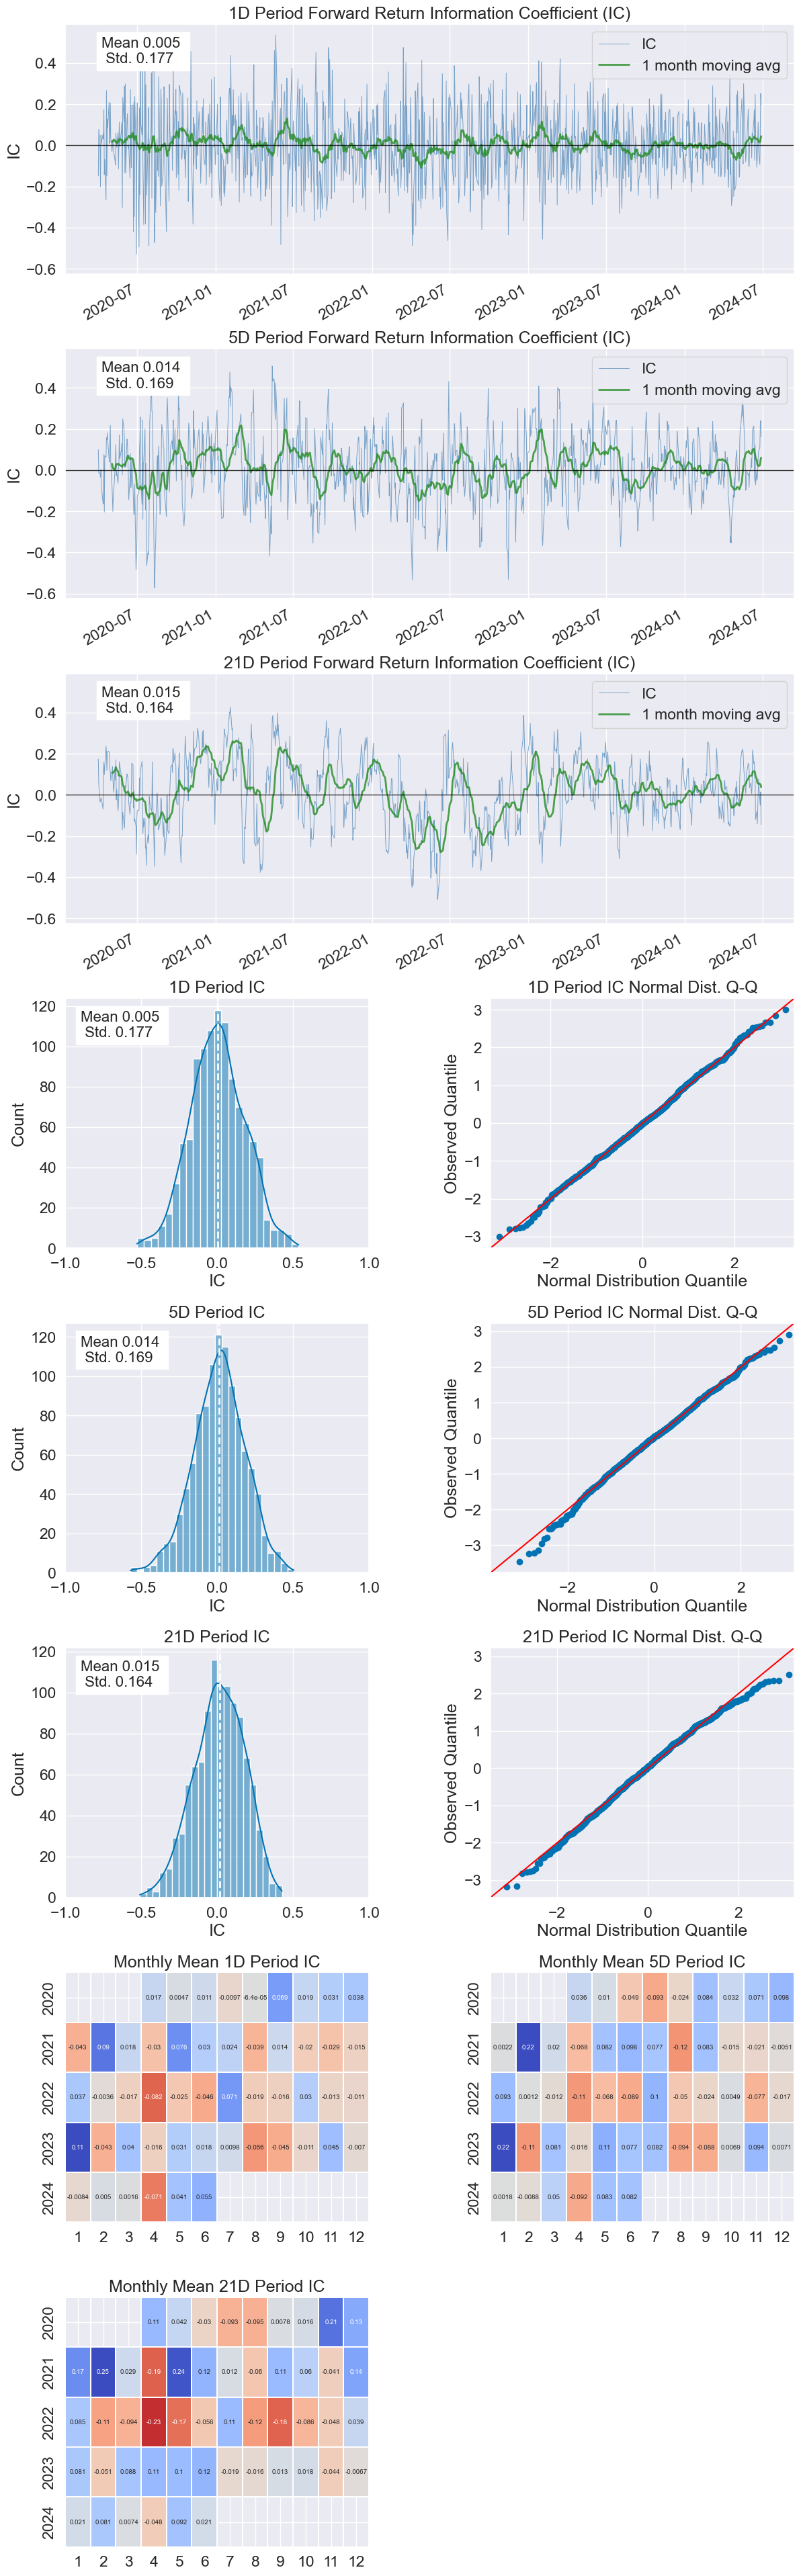

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\alphalens\utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,21D
Quantile 1 Mean Turnover,0.2290,0.5980,0.6950
Quantile 2 Mean Turnover,0.4720,0.7400,0.7650
Quantile 3 Mean Turnover,0.5210,0.7570,0.7850
Quantile 4 Mean Turnover,0.4710,0.7350,0.7720
Quantile 5 Mean Turnover,0.2210,0.5180,0.6360


,1D,5D,21D
Mean Factor Rank Autocorrelation,0.9020,0.4790,0.2800


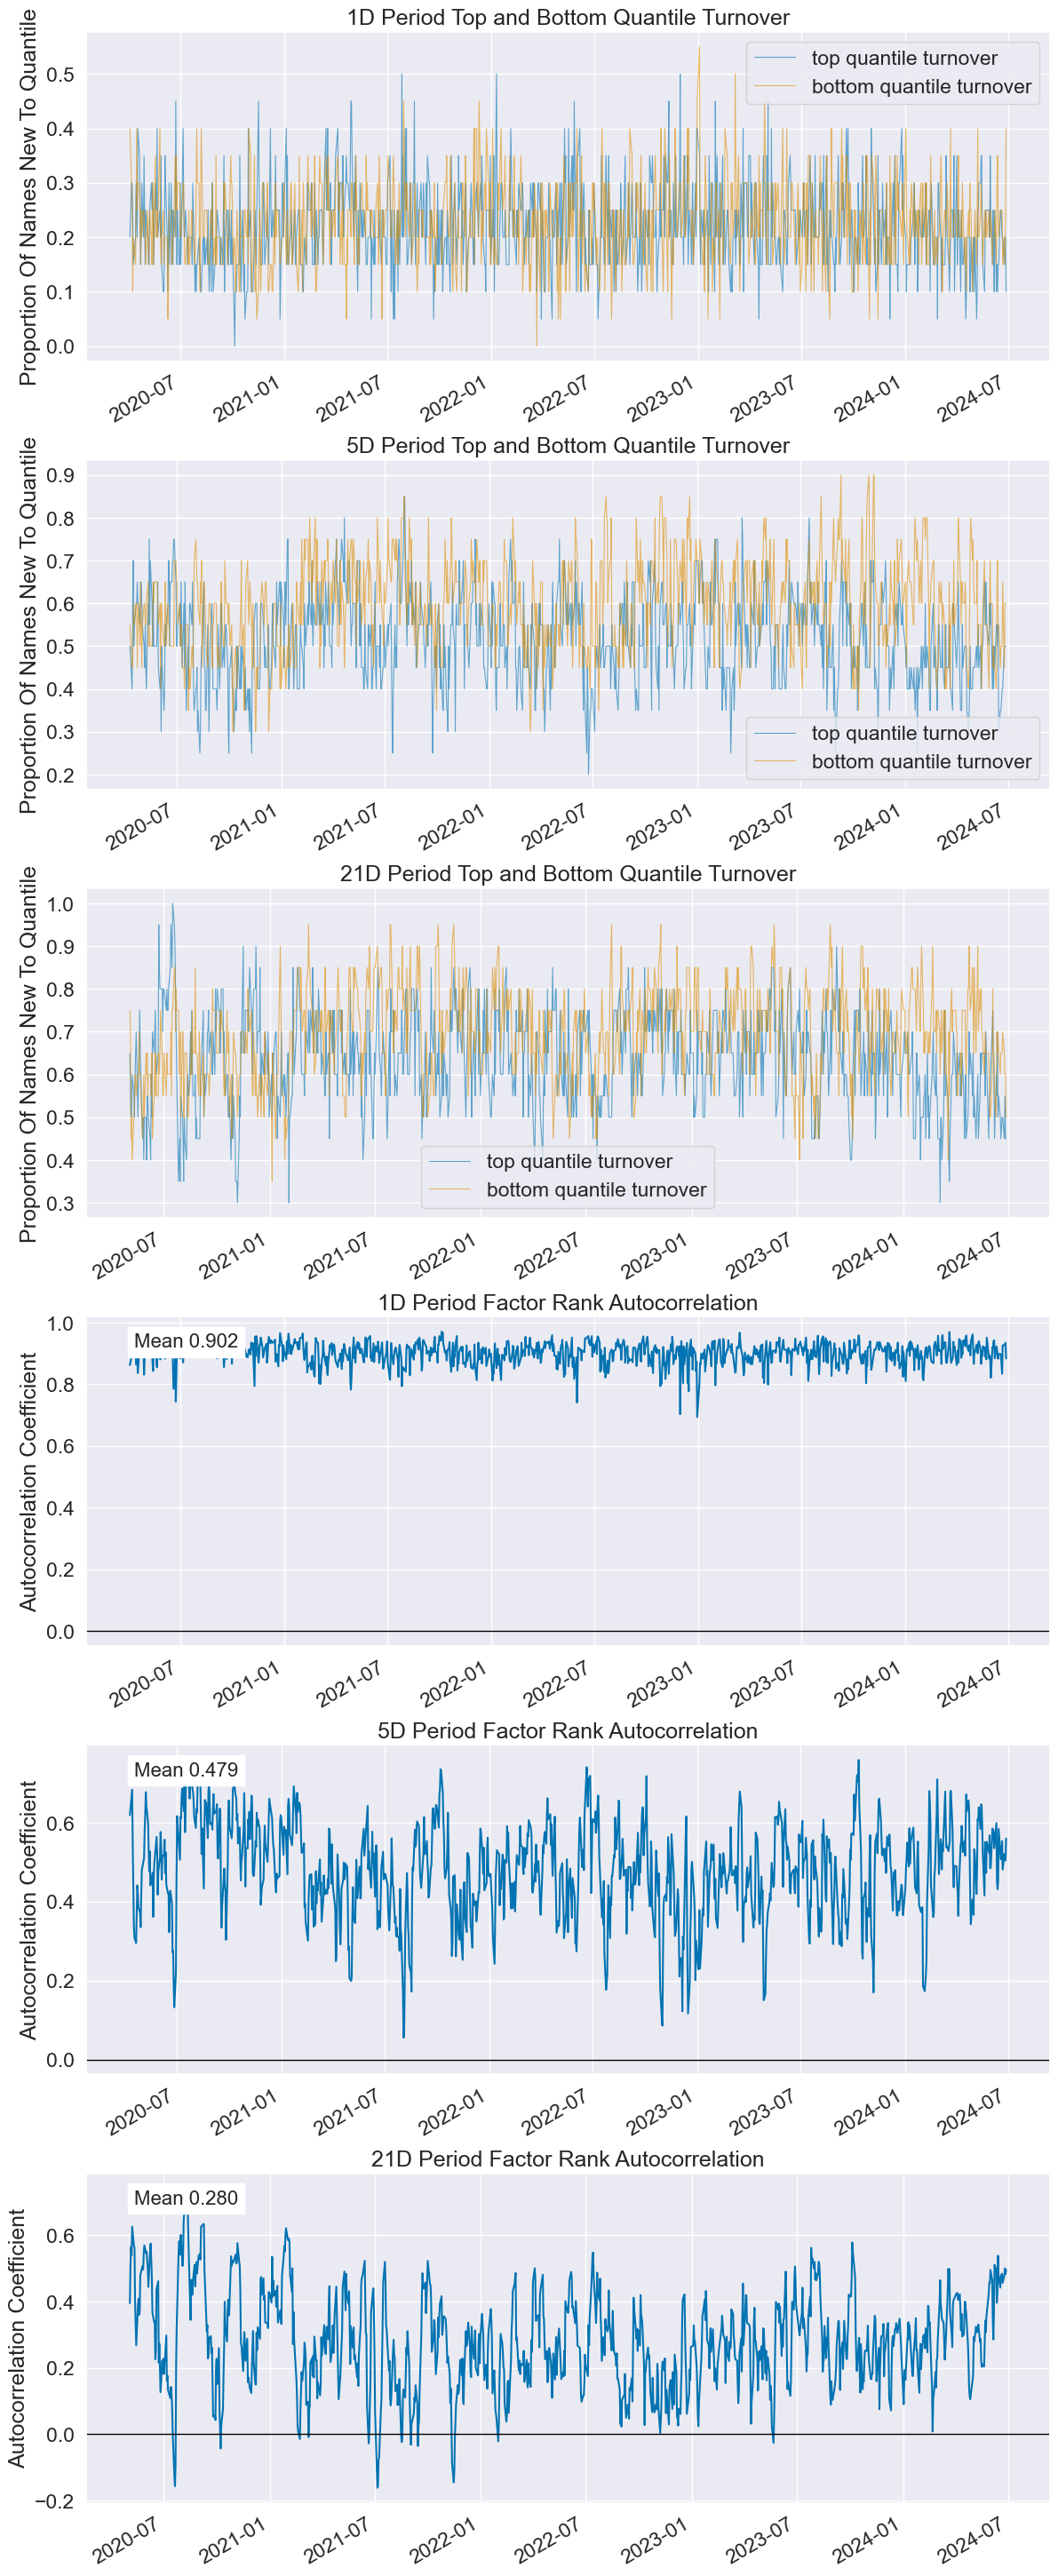

In [8]:
# --- Edit after reviewing the §4.1 summary table ---
TEAR_MODE = "reversal"        # ratio | log_ratio | reversal
TEAR_GK_WINDOW = 5            # gkW
TEAR_REALISED_WINDOW = 63     # realW

tear_col = gk_factor_col(TEAR_MODE, TEAR_GK_WINDOW, TEAR_REALISED_WINDOW)
print(f"Tear sheet factor: {tear_col}")
tear_factor_data = run_full_tear(panel, tear_col, prices)


## Conclusion

`ratio` / `log_ratio` rows often show **negative** 5d IC because the hypothesis is that a high GK/realised vol ratio predicts *lower* forward returns; `reversal` flips that signal so higher values map to higher expected returns and therefore **positive** IC. With `normalize=True`, `ratio` and `reversal` are essentially the same cross-sectional idea with opposite orientation — pick by signed IC in the intended long/short direction (prefer `reversal` for a GBM-ready “higher = better” feature), not by largest absolute IC across both modes.
